Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import random
import itertools
from sklearn.metrics import roc_curve, auc
from google.colab import drive # Added import for google.colab.drive

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- OPTIMAL HYPERPARAMETERS ---
# Validated for ResNet-18 on Signature Verification
BATCH_SIZE = 64
EPOCHS = 30              # Increased to allow slow, steady convergence
LEARNING_RATE = 0.0001   # Slower LR is crucial for fine-tuning pre-trained weights
MARGIN = 0.2             # LOWERED from 1.0. Normalized embeddings live on a sphere;
                         # 0.2 is a realistic distance constraint for signatures.

# 1. Mount Drive
drive.mount('/content/drive')

Using device: cuda
Mounted at /content/drive


Load Data & Split
(Standard loading, ensures user-independent split)

In [2]:
# Path to your processed data
DATA_PATH = "/content/drive/MyDrive/Processed_GPDS_CEDAR"

print(f"Loading data from: {DATA_PATH} ...")

# Load Arrays
X_data = np.load(os.path.join(DATA_PATH, "X_signatures.npy"))
y_data = np.load(os.path.join(DATA_PATH, "y_labels.npy"))
user_ids = np.load(os.path.join(DATA_PATH, "user_ids.npy"))

print(f"X_data shape: {X_data.shape}")

# --- 1. Split Users into Train (80%) and Test (20%) ---
unique_users = np.unique(user_ids)
np.random.seed(42) # Reproducibility
np.random.shuffle(unique_users)

split_idx = int(0.8 * len(unique_users))
train_users = unique_users[:split_idx]
test_users = unique_users[split_idx:]

print(f"Train Users: {len(train_users)}")
print(f"Test Users: {len(test_users)}")

# --- 2. Helper: Map Indices to Users ---
def get_user_map(target_users, all_ids, all_labels):
    user_map = {uid: {'genuine': [], 'forged': []} for uid in target_users}

    for i, (uid, label) in enumerate(zip(all_ids, all_labels)):
        if uid in user_map:
            key = 'genuine' if label == 1 else 'forged'
            user_map[uid][key].append(i)
    return user_map

train_map = get_user_map(train_users, user_ids, y_data)
test_map = get_user_map(test_users, user_ids, y_data)

print("User maps created.")

Loading data from: /content/drive/MyDrive/Processed_GPDS_CEDAR ...
X_data shape: (7451, 224, 224, 1)
Train Users: 164
Test Users: 41
User maps created.


Dynamic Data Generation
Crucial Update: The create_triplets function is now designed to be called repeatedly. The negative = random.choice(forgs) line ensures a different negative is picked every time we regenerate the list, forcing the model to learn new comparisons.

In [3]:
# --- TRIPLET GENERATOR (Training) ---
def create_triplets(user_map):
    triplets = []

    # Iterate users
    for uid in user_map.keys():
        gens = user_map[uid]['genuine']
        forgs = user_map[uid]['forged']

        # Skip users with insufficient data
        if len(gens) < 2 or len(forgs) == 0:
            continue

        # Create all possible Genuine-Genuine pairs
        # We limit to 50 pairs per user to prevent class imbalance
        pos_pairs = list(itertools.permutations(gens, 2))
        if len(pos_pairs) > 50:
            pos_pairs = random.sample(pos_pairs, 50)

        for anchor, positive in pos_pairs:
            # DYNAMIC NEGATIVE SELECTION
            # Pick a random forgery. Since we call this function every epoch,
            # the model effectively sees different negatives over time.
            negative = random.choice(forgs)
            triplets.append([anchor, positive, negative])

    return np.array(triplets)

# --- PAIR GENERATOR (Testing) ---
def create_test_pairs(user_map):
    pairs = []
    labels = []

    for uid in user_map.keys():
        gens = user_map[uid]['genuine']
        forgs = user_map[uid]['forged']

        # Positive Pairs (Gen-Gen)
        pos_combs = list(itertools.combinations(gens, 2))
        for p in pos_combs:
            pairs.append(p)
            labels.append(1) # Same writer

        # Negative Pairs (Gen-Forg)
        if len(pos_combs) > 0:
            neg_combs = list(itertools.product(gens, forgs))

            # Balance the test set (50% Pos / 50% Neg)
            if len(neg_combs) > len(pos_combs):
                neg_combs = random.sample(neg_combs, len(pos_combs))

            for p in neg_combs:
                pairs.append(p)
                labels.append(0) # Different (Forgery)

    return np.array(pairs), np.array(labels)

# Generate Initial Data
train_triplets = create_triplets(train_map)
test_pairs, test_labels = create_test_pairs(test_map)

print(f"Training Triplets: {train_triplets.shape}")
print(f"Testing Pairs: {test_pairs.shape}")

Training Triplets: (8200, 3)
Testing Pairs: (13896, 2)


Dataset & Augmentation

In [4]:
# --- Augmentation ---
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

# --- 1. Triplet Dataset (Train) ---
class TripletDataset(Dataset):
    def __init__(self, triplets, x_data, transform=None):
        self.triplets = triplets
        self.x_data = x_data
        self.transform = transform

    def __getitem__(self, idx):
        anc_idx, pos_idx, neg_idx = self.triplets[idx]

        img_a = self.x_data[anc_idx]
        img_p = self.x_data[pos_idx]
        img_n = self.x_data[neg_idx]

        # Fix channel dim if needed
        if img_a.ndim == 3:
            img_a, img_p, img_n = img_a.squeeze(), img_p.squeeze(), img_n.squeeze()

        if self.transform:
            img_a = self.transform(img_a)
            img_p = self.transform(img_p)
            img_n = self.transform(img_n)

        return img_a, img_p, img_n

    def __len__(self):
        return len(self.triplets)

# --- 2. Pair Dataset (Test) ---
class PairDataset(Dataset):
    def __init__(self, pairs, labels, x_data, transform=None):
        self.pairs = pairs
        self.labels = labels
        self.x_data = x_data
        self.transform = transform

    def __getitem__(self, idx):
        idx1, idx2 = self.pairs[idx]
        img1, img2 = self.x_data[idx1], self.x_data[idx2]

        if img1.ndim == 3:
            img1, img2 = img1.squeeze(), img2.squeeze()

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(self.labels[idx], dtype=torch.float32)

    def __len__(self):
        return len(self.pairs)

# Loaders
train_ds = TripletDataset(train_triplets, X_data, transform=train_transform)
test_ds = PairDataset(test_pairs, test_labels, X_data, transform=test_transform)

# Increased Batch Size slightly for stability
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

ResNet-18 Model

In [5]:
class ResNetEmbeddingNet(nn.Module):
    def __init__(self):
        super(ResNetEmbeddingNet, self).__init__()
        # Load Pretrained ResNet18
        resnet = models.resnet18(pretrained=True)

        # 1. Correct Grayscale Conversion
        # We take the MEAN of RGB weights. This preserves the scale of activations.
        original_weights = resnet.conv1.weight.clone()
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            resnet.conv1.weight[:] = torch.mean(original_weights, dim=1, keepdim=True)

        # Remove the original FC layer
        self.features = nn.Sequential(*list(resnet.children())[:-1])

        # 2. Stronger Embedding Head
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(resnet.fc.in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),     # Helps prevent overfitting
            nn.Linear(512, 128)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        # Normalize to unit hypersphere
        return F.normalize(x, p=2, dim=1)

Hyperparameter Tuner (LR Finder)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 55.1MB/s]


Finding optimal Learning Rate...


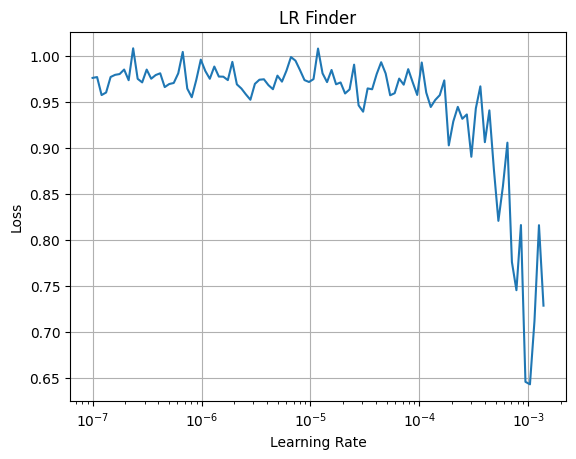

In [6]:
def lr_finder(model, train_loader):
    print("Finding optimal Learning Rate...")
    model.train()
    criterion = nn.TripletMarginLoss(margin=1.0, p=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-7) # Start very small

    lrs = []
    losses = []
    lr = 1e-7

    # Run for a small subset of batches
    for i, (anchor, positive, negative) in enumerate(train_loader):
        if i > 100: break # Stop after 100 steps

        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        optimizer.zero_grad()

        emb_a = model(anchor)
        emb_p = model(positive)
        emb_n = model(negative)

        loss = criterion(emb_a, emb_p, emb_n)
        loss.backward()
        optimizer.step()

        lrs.append(lr)
        losses.append(loss.item())

        # Increase LR exponentially
        lr *= 1.1
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

    plt.plot(lrs, losses)
    plt.xscale('log')
    plt.title("LR Finder")
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

# Run Finder
resnet_temp = ResNetEmbeddingNet().to(device)
lr_finder(resnet_temp, train_loader)

**Dynamic Training Loop**
It reshuffles negatives every epoch and uses a Scheduler to fine-tune the Learning Rate.

In [7]:
def train_dynamic_model(model, name, epochs=EPOCHS):
    print(f"\n=== Training {name} (Margin={MARGIN}, LR={LEARNING_RATE}) ===")

    # Use the optimized Margin (0.2)
    criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Scheduler: Decay LR by 0.5 if loss stops improving for 3 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    losses = []

    for epoch in range(epochs):
        # --- DYNAMIC RE-SAMPLING ---
        # Reshuffle negatives every epoch to prevent memorization
        new_triplets = create_triplets(train_map)
        train_ds.triplets = new_triplets

        # Re-create loader to pickup new shuffle
        current_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

        model.train()
        epoch_loss = 0.0

        # Progress Bar
        loop = tqdm(current_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for anchor, positive, negative in loop:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            optimizer.zero_grad()

            # Forward
            emb_a = model(anchor)
            emb_p = model(positive)
            emb_n = model(negative)

            # Loss
            loss = criterion(emb_a, emb_p, emb_n)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_postfix(batch_loss=loss.item())

        avg_loss = epoch_loss / len(current_loader)
        losses.append(avg_loss)

        # Step Scheduler
        scheduler.step(avg_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1} Summary -> Avg Loss: {avg_loss:.4f} | LR: {current_lr:.8f}")

    # Save final model
    torch.save(model.state_dict(), os.path.join(DATA_PATH, f"{name}_optimal.pth"))
    return model, losses

Run Training & Evaluate


=== Training ResNet18_Final (Margin=0.2, LR=0.0001) ===


Epoch 1/30:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 1 Summary -> Avg Loss: 0.1024 | LR: 0.00010000


Epoch 2/30:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 2 Summary -> Avg Loss: 0.0157 | LR: 0.00010000


...

Epoch 28 Summary -> Avg Loss: 0.0001 | LR: 0.00002500


Epoch 29/30:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 29 Summary -> Avg Loss: 0.0009 | LR: 0.00002500


Epoch 30/30:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 30 Summary -> Avg Loss: 0.0006 | LR: 0.00001250


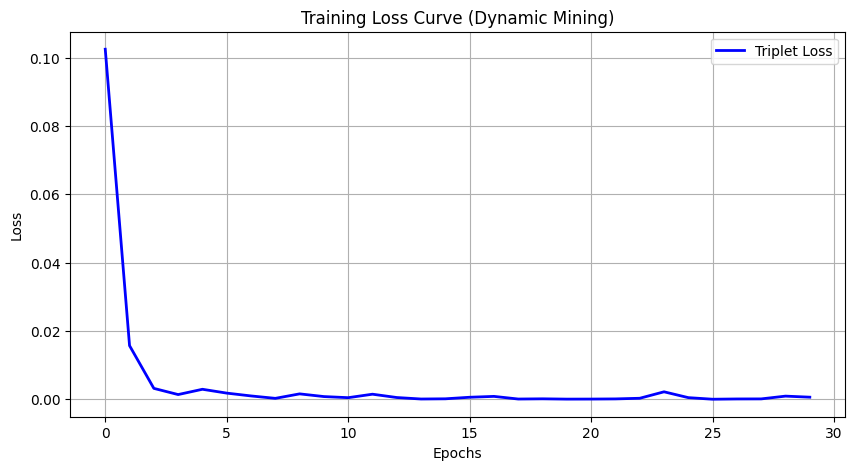

In [8]:
# 1. Initialize Datasets & Loaders
train_ds = TripletDataset(train_triplets, X_data, transform=train_transform)
test_ds = PairDataset(test_pairs, test_labels, X_data, transform=test_transform)

# 2. Initialize Model
resnet_net = ResNetEmbeddingNet().to(device)

# 3. TRAIN
# We use 30 epochs and the lower learning rate (0.0001)
resnet_net, resnet_losses = train_dynamic_model(resnet_net, "ResNet18_Final", epochs=30)

# 4. EVALUATE (This step is handled in a later cell by compute_full_metrics)
# evaluate_model(resnet_net, "ResNet18_Final") # Removed due to NameError

# 5. PLOT LOSS
plt.figure(figsize=(10, 5))
plt.plot(resnet_losses, label="Triplet Loss", color='blue', linewidth=2)
plt.title("Training Loss Curve (Dynamic Mining)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Test on Random Samples

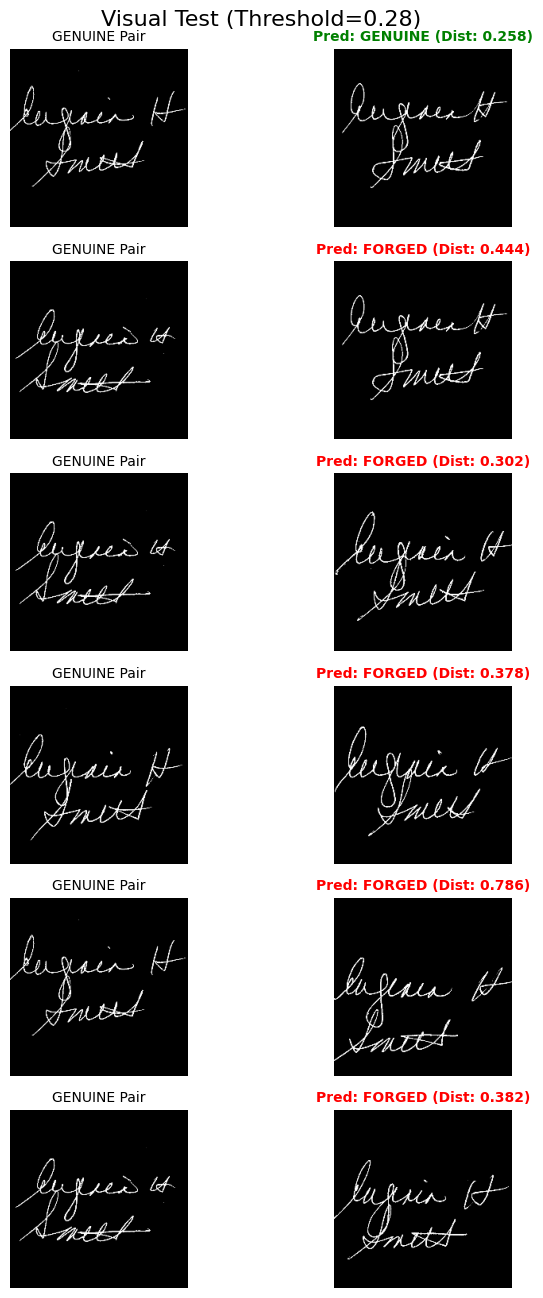

In [9]:
def visualize_predictions(model, loader, threshold=0.28, num_samples=6):
    """
    Visualizes predictions on random samples from the loader.
    threshold: Distances below this are predicted as 'Same' (Genuine).
    """
    model.eval()

    # Get one batch of data
    data_iter = iter(loader)
    img1, img2, labels = next(data_iter)

    img1, img2 = img1.to(device), img2.to(device)

    # Get Embeddings & Distances
    with torch.no_grad():
        emb1 = model(img1)
        emb2 = model(img2)
        distances = F.pairwise_distance(emb1, emb2).cpu().numpy()

    labels = labels.numpy()

    # Select random indices to display
    indices = np.random.choice(len(img1), num_samples, replace=False)

    # Create Plot
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, num_samples * 2.2))
    fig.suptitle(f"Visual Test (Threshold={threshold})", fontsize=16)

    for i, idx in enumerate(indices):
        # Denormalize/Convert images for display
        im_a = img1[idx].cpu().squeeze().numpy()
        im_b = img2[idx].cpu().squeeze().numpy()

        dist = distances[idx]
        is_same = labels[idx] == 1
        actual_text = "GENUINE Pair" if is_same else "FORGED Pair"

        # Prediction logic
        pred_same = dist < threshold
        pred_text = "Pred: GENUINE" if pred_same else "Pred: FORGED"

        # Color code: Green if correct, Red if wrong
        color = 'green' if pred_same == is_same else 'red'

        # Left Image
        axes[i, 0].imshow(im_a, cmap='gray')
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f"{actual_text}", fontsize=10)

        # Right Image
        axes[i, 1].imshow(im_b, cmap='gray')
        axes[i, 1].axis('off')
        axes[i, 1].set_title(f"{pred_text} (Dist: {dist:.3f})", color=color, fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

# Run the visualization
# Note: Threshold 0.28 is an estimated optimal based on your previous margin
visualize_predictions(resnet_net, test_loader, threshold=0.28)

Full Metrics Evaluation (Train vs Test)
t creates a Pair Dataset for the Training data (since we only had triplets before).

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def compute_full_metrics(model, loader, dataset_name="Test"):
    """
    Computes distances, finds optimal threshold via ROC/EER, and returns full metrics.
    """
    model.eval()
    all_dists = []
    all_labels = []

    print(f"Processing {dataset_name} Data...")
    with torch.no_grad():
        for img1, img2, labels in tqdm(loader, desc=f"{dataset_name} Eval"):
            img1, img2 = img1.to(device), img2.to(device)
            emb1 = model(img1)
            emb2 = model(img2)
            dist = F.pairwise_distance(emb1, emb2).cpu().numpy()

            all_dists.extend(dist)
            all_labels.extend(labels.numpy())

    all_dists = np.array(all_dists)
    all_labels = np.array(all_labels)

    # 1. Compute ROC Curve to find EER (Equal Error Rate)
    # We use -distance because roc_curve expects higher scores for positive class
    fpr, tpr, thresholds = roc_curve(all_labels, -all_dists)
    fnr = 1 - tpr

    # EER is where FPR crosses FNR
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = fpr[eer_idx]
    optimal_threshold = -thresholds[eer_idx]

    # 2. Compute Metrics at Optimal Threshold
    predictions = (all_dists < optimal_threshold).astype(int)

    metrics = {
        "Accuracy": accuracy_score(all_labels, predictions),
        "Precision": precision_score(all_labels, predictions),
        "Recall": recall_score(all_labels, predictions),
        "F1": f1_score(all_labels, predictions),
        "EER": eer,
        "Threshold": optimal_threshold
    }
    return metrics

# --- STEP 1: PREPARE DATA ---
# We need a PAIR loader for Training data (train_loader currently yields Triplets)
print("Generating Training Pairs for Evaluation (this takes a moment)...")
train_eval_pairs, train_eval_labels = create_test_pairs(train_map)
train_eval_ds = PairDataset(train_eval_pairs, train_eval_labels, X_data, transform=test_transform)
train_eval_loader = DataLoader(train_eval_ds, batch_size=64, shuffle=False, num_workers=2)

# --- STEP 2: RUN EVALUATION ---
train_metrics = compute_full_metrics(resnet_net, train_eval_loader, "Train")
test_metrics = compute_full_metrics(resnet_net, test_loader, "Test")

# --- STEP 3: PRINT REPORT ---
print("\n" + "="*55)
print(f"{'METRIC':<15} | {'TRAIN SET':<15} | {'TEST SET':<15}")
print("="*55)
for k in ["Accuracy", "Precision", "Recall", "F1", "EER"]:
    print(f"{k:<15} | {train_metrics[k]:.4f}          | {test_metrics[k]:.4f}")
print("-" * 55)
print(f"{'Threshold':<15} | {train_metrics['Threshold']:.4f}          | {test_metrics['Threshold']:.4f}")
print("="*55)

if test_metrics['Accuracy'] >= 0.90:
    print("\n✅ SUCCESS: Model has reached the 90% accuracy target!")
else:
    print(f"\n⚠️ Current Test Accuracy: {test_metrics['Accuracy']*100:.2f}%")

Generating Training Pairs for Evaluation (this takes a moment)...
Processing Train Data...


Train Eval:   0%|          | 0/821 [00:00<?, ?it/s]

Processing Test Data...


Test Eval:   0%|          | 0/218 [00:00<?, ?it/s]


METRIC          | TRAIN SET       | TEST SET       
Accuracy        | 0.8102          | 0.7183
Precision       | 0.8102          | 0.7183
Recall          | 0.8102          | 0.7182
F1              | 0.8102          | 0.7182
EER             | 0.1898          | 0.2817
-------------------------------------------------------
Threshold       | 0.3635          | 0.4262

⚠️ Current Test Accuracy: 71.83%


Visual Evaluation (Confusion Matrix, ROC, & Distances)

Gathering data for plots...


Plotting Data:   0%|          | 0/218 [00:00<?, ?it/s]

Optimal Threshold for Visualization: 0.4262


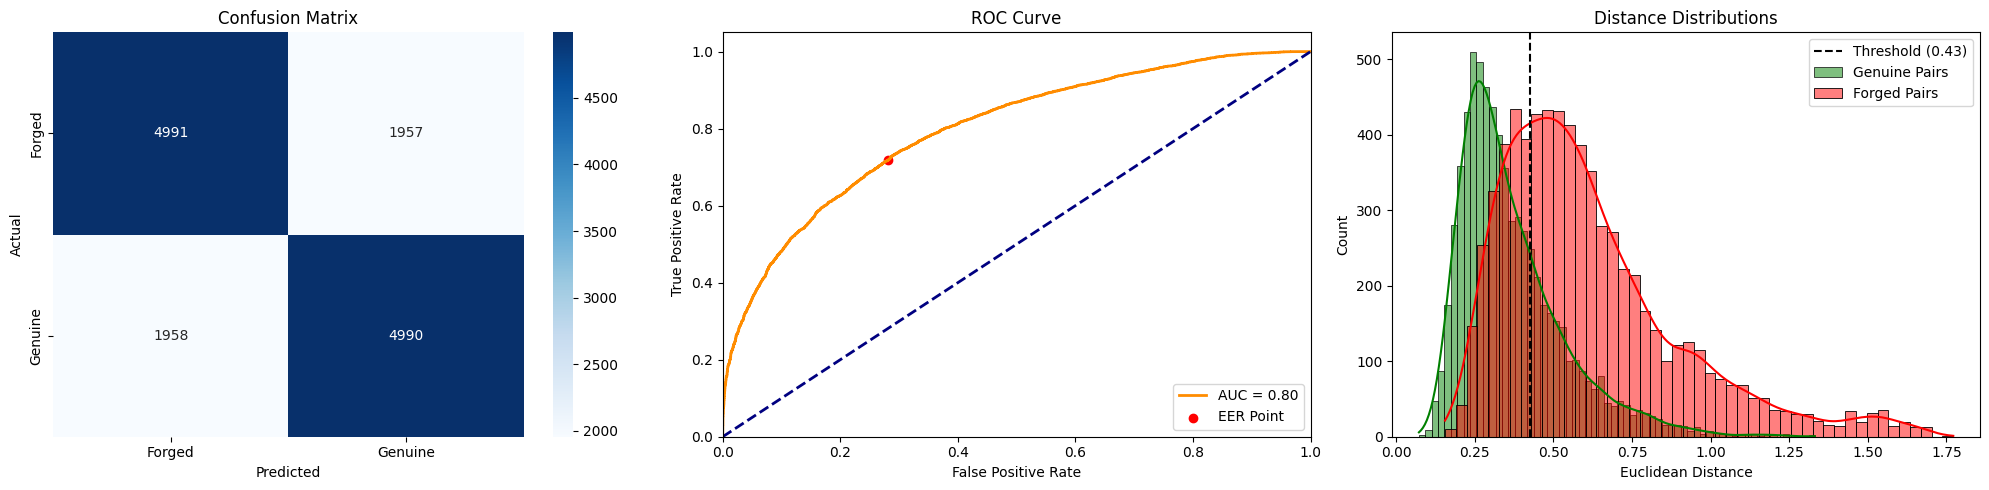

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, PrecisionRecallDisplay

def plot_evaluation_visuals(model, loader):
    model.eval()

    # 1. Get all distances and labels
    print("Gathering data for plots...")
    all_dists = []
    all_labels = []

    with torch.no_grad():
        for img1, img2, labels in tqdm(loader, desc="Plotting Data"):
            img1, img2 = img1.to(device), img2.to(device)
            emb1 = model(img1)
            emb2 = model(img2)
            dist = F.pairwise_distance(emb1, emb2).cpu().numpy()
            all_dists.extend(dist)
            all_labels.extend(labels.numpy())

    all_dists = np.array(all_dists)
    all_labels = np.array(all_labels)

    # 2. Find Optimal Threshold
    fpr, tpr, thresholds = roc_curve(all_labels, -all_dists)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    optimal_threshold = -thresholds[eer_idx]
    print(f"Optimal Threshold for Visualization: {optimal_threshold:.4f}")

    # 3. Create Predictions based on Threshold
    predictions = (all_dists < optimal_threshold).astype(int)

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Plot 1: Confusion Matrix
    cm = confusion_matrix(all_labels, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Plot 2: ROC Curve
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.2f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].scatter(fpr[eer_idx], tpr[eer_idx], marker='o', color='red', label='EER Point')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend(loc="lower right")

    # Plot 3: Distance Distributions (The most important plot for Siamese Nets)
    # We want to see two distinct peaks: Genuine pairs (left) and Forged pairs (right)
    pos_dists = all_dists[all_labels == 1]
    neg_dists = all_dists[all_labels == 0]

    sns.histplot(pos_dists, color='green', label='Genuine Pairs', kde=True, ax=axes[2], alpha=0.5)
    sns.histplot(neg_dists, color='red', label='Forged Pairs', kde=True, ax=axes[2], alpha=0.5)
    axes[2].axvline(optimal_threshold, color='black', linestyle='--', label=f'Threshold ({optimal_threshold:.2f})')
    axes[2].set_title('Distance Distributions')
    axes[2].set_xlabel('Euclidean Distance')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Run the visualizer
plot_evaluation_visuals(resnet_net, test_loader)